# Applying Kernel PCA on the Swiss Roll Dataset

In [1]:
from sklearn.datasets import make_swiss_roll
from mpl_toolkits.mplot3d import Axes3D

In [2]:
import numpy as np 
import matplotlib.pyplot as plt 

In [22]:
def generate_swiss_roll(n_samples=1000, noise=0.2):
    t = 1.5 * np.pi * (1 + 2 * np.random.rand(1, n_samples))
    x = t * np.cos(t)
    y = 21 * np.random.rand(1, n_samples)
    z = t * np.sin(t)
    data = np.vstack((x, y, z)).T + noise * np.random.randn(n_samples, 3)
    return data

# Generate the Swiss Roll dataset
swiss_roll = generate_swiss_roll()

### Visualize the Swiss Roll Dataset

/var/folders/s0/9txpn9vj4gl5nq6jwlhnp3m00000gn/T/ipykernel_95317/3992820084.py:3: UserWarning: No data for colormapping provided via 'c'. Parameters 'cmap' will be ignored
  ax.scatter(swiss_roll[:, 0], swiss_roll[:, 1], swiss_roll[:, 2], c='b', cmap=plt.cm.Spectral)


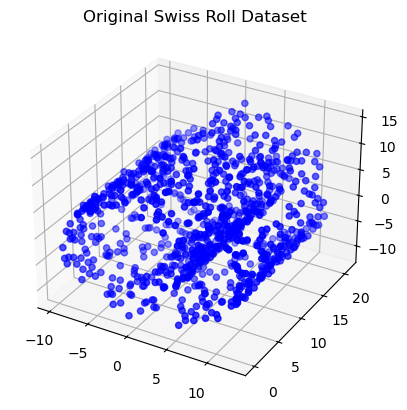

In [23]:
fig = plt.figure()
ax = fig.add_subplot(111, projection='3d')
ax.scatter(swiss_roll[:, 0], swiss_roll[:, 1], swiss_roll[:, 2], c='b', cmap=plt.cm.Spectral)
ax.set_title("Original Swiss Roll Dataset")
plt.show()

### <u>Define Kernel function : RBF</u>

In [24]:
def rbf(X, sigma = 1.0): 
    pairwise_dists = np.sum(X**2 , axis=1).reshape(-1, 1) + np.sum(X**2 , axis=1) - 2 * np.dot(X , X.T)
    return np.exp(-pairwise_dists/(2 * sigma ** 2))

### Kernel PCA steps: 

<ul>
<li>Compute the kernel matrix.</li>
<li>Center the kernel matrix.</li>
<li>Calculate the eigenvalues and eigenvectors of the centered kernel matrix.</li>
<li>Sort the eigenvectors by decreasing eigenvalues.</li>
<li>Select the top k scaled eigenvectors as the new feature vectors.</li>
</ul>

In [25]:
def Kernel_PCA(X , n_comps=2, sigma = 1.0): 
    # Compute the Kernel Matrix 
    K = rbf(X, sigma)
    
    # Center the Kernel Matrix 
    n = K.shape[0]
    one_n = np.ones((n , n))/n
    K_centered = K - one_n.dot(K) - K.dot(one_n) + one_n.dot(K).dot(one_n)
    
    # calculate the eigenvalues and eigenvectors of the K_centered
    eigvals, eigvecs = np.linalg.eigh(K_centered)
    
    # sort the eigenvectors by decreasing eigenvalues 
    eigvals, eigvecs = eigvals[::-1], eigvecs[::-1]
    
    # select the top n_comps scaled eigenvectors 
    alphas = eigvecs[:, :n_comps] / np.sqrt(eigvals[:n_comps])
    
    
    return alphas

n_comps = 2 
alphas = Kernel_PCA(swiss_roll, n_comps, sigma=1.0)

### Visualizing the Transformed Data 

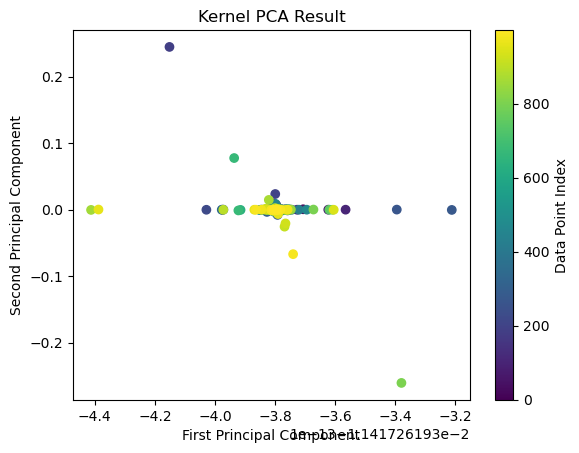

In [26]:
# Separate the transformed data into two components
pc1 = alphas[:, 0]
pc2 = alphas[:, 1]

# Create a scatter plot with two different colors for the two PCs
plt.scatter(pc1, pc2, c=range(len(pc1)))
plt.title("Kernel PCA Result")
plt.xlabel("First Principal Component")
plt.ylabel("Second Principal Component")
plt.colorbar(label='Data Point Index')
plt.show()